# Drivers 50 — CoastSat as a second response dataset
Repeats the driver analysis with **CoastSat satellite-derived shoreline trends
(1999–2026; 33,422 transects, 604 sites)** and compares them with the NZCCD.

- Sign convention verified: CoastSat `trend` and NZCCD WLR are positively
  correlated (ρ≈+0.40; +0.52 within 50 m) → positive = accretion in both.
- Drivers are attached from the nearest NZCCD transect (≤300 m; they vary on
  km scales), except beach-face slope which is CoastSat's own per-transect slope.
- Three NZCCD comparison layers: nearest-transect WLR (full period), NZCCD
  rates on the **same** CoastSat transect geometry (`rates_with_timeseries_
  CoastSat_intersects.parquet`), and a **post-1999 same-period** NZCCD recompute
  (closed-form OLS from `drivers.epochs`) — this isolates *period* from *method*.
- Satellite-era epochs: per-transect OLS trends 1999–2012 vs 2013–2026 from the
  per-site tidally corrected series (Landsat 5/7 vs 8/9 era — sensor caveat).
- Inference: block bootstrap with CoastSat **site** as the block; NZCCD
  correlations are recomputed on the same matched rows for a like-for-like test.

In [1]:
import pandas as pd
from drivers import common
from drivers.correlations import STATS_DIR

path = common.DRIVER_DATA / "coastsat_master.parquet"
if not path.exists():
    from drivers.coastsat import build, run_stats
    df = build(); run_stats(df)
else:
    df = pd.read_parquet(path)
    if not (STATS_DIR / "coastsat_correlations.csv").exists():
        from drivers.coastsat import run_stats; run_stats(df)
print(df.shape); df[["id","site_id","cs_trend","cs_n_obs","cs_r2","beach_slope_face","nz_WLR","nz_dist_m","nzst_WLR","nzst_LRR_post1999"]].describe().round(3)

(33422, 64)


,cs_trend,cs_n_obs,cs_r2,beach_slope_face,nz_WLR,nz_dist_m,nzst_WLR,nzst_LRR_post1999
count,33422.000,33422.000,33422.000,33422.000,23725.000,23725.000,22509.000,12312.000
mean,0.117,462.448,0.246,0.077,0.184,9.036,0.116,0.039
std,1.871,164.779,0.253,0.047,1.371,32.112,1.245,2.410
min,-37.042,109.000,0.000,0.010,-10.410,0.001,-14.960,-28.675
25%,-0.377,352.000,0.035,0.040,-0.230,1.355,-0.250,-0.454
50%,0.068,444.000,0.149,0.065,0.050,2.682,0.050,-0.007
75%,0.553,587.000,0.396,0.100,0.460,4.040,0.460,0.489
max,25.786,1065.000,0.976,0.200,18.610,299.730,31.200,39.997


## NZCCD vs CoastSat agreement
Agreement improves from ρ=0.41 to 0.52 when the NZCCD rate is recomputed for the same post-1999 window on the same transect — the residual disagreement is mostly *period*, not *method*.

In [2]:
pd.read_csv(STATS_DIR / "coastsat_comparison.csv").query("scope=='all'")

,scope,comparison,n,spearman,pearson,sign_agreement,median_abs_diff
0,all,CoastSat 1999-2026 vs NZCCD WLR full period (n...,23089,0.410,0.358,0.641,0.452
1,all,CoastSat 1999-2026 vs NZCCD WLR full period (s...,22509,0.405,0.343,0.640,0.465
2,all,CoastSat 1999-2026 vs NZCCD LRR post-1999 (sam...,12312,0.524,0.528,0.684,0.474
3,all,CoastSat 1999-2026 vs NZCCD EPR post-1999 (sam...,20775,0.489,0.021,0.664,0.578


## Driver correlations: record length matters, method doesn't
On the same transects, the 85-year NZCCD rates correlate with the drivers
(beach slope −0.23, storminess +0.19, erodibility +0.17, rock age −0.17) but the
27-year CoastSat trends barely do — **and neither do the NZCCD rates when
restricted to post-1999**. Post-1999 NZCCD and CoastSat agree with each other
(e.g. mean Hs −0.15 vs −0.15): recent-decade change relates to drivers
differently (wave energy negative, seismicity positive) than long-term change.

In [3]:
c = pd.read_csv(STATS_DIR / "coastsat_correlations.csv")
c = c.reindex(c.rho_nzccd_same_transect.abs().sort_values(ascending=False).index)
c[["driver","rho_nzccd_same_transect","rho_nzccd_post1999","rho_coastsat_on_post1999_rows","rho_coastsat","n_post1999","n_sites"]].round(3).reset_index(drop=True)

,driver,rho_nzccd_same_transect,rho_nzccd_post1999,rho_coastsat_on_post1999_rows,rho_coastsat,n_post1999,n_sites
0,beach_slope_face,-0.230,-0.048,-0.006,-0.026,12312,604
1,storm_hrs_gt4m_yr,0.191,-0.053,-0.047,0.020,12167,380
2,hs_p99,0.175,-0.068,-0.054,-0.008,12167,380
3,geol_age_ma,-0.172,-0.095,-0.105,-0.031,12167,380
4,erodibility_ord,0.170,0.047,-0.048,0.001,12167,380
5,tanbeta_nearshore,0.151,0.094,0.201,0.154,10890,357
6,vlm_mm_yr,-0.121,-0.059,-0.052,-0.047,12167,380
7,river_supply_idx,-0.114,-0.031,-0.051,-0.042,12167,380
8,wave_incidence_deg,-0.105,-0.045,-0.070,-0.084,12167,380
9,cge_mean,0.100,-0.127,-0.127,-0.070,12167,380


In [4]:
pd.read_csv(STATS_DIR / "coastsat_categorical.csv").round(3)

,driver,eps2_coastsat,eps2_nzccd_matched,k,n
0,Typology,0.149,0.823,5,23400
1,SubTypolog,0.007,0.004,3,19521
2,SHORE_TYPE,0.029,0.135,9,21484
3,EXPOSURE,0.002,0.001,2,22086
4,HINTERLAND,0.013,0.074,6,22165
5,lith_class,0.002,0.033,4,23473
6,erodibility,NaN,NaN,1,1380


## Satellite-era epochs (1999–2012 vs 2013–2026)
Median trend flips from −0.06 to +0.18 m/yr (eroding share 53% → 42%) with very low per-transect persistence (ρ=0.07). Caveat: the split coincides with the Landsat 5/7 → 8/9 transition; short-window trends are noisy.

In [5]:
pd.read_csv(STATS_DIR / "coastsat_epoch_summary.csv").round(3)

,scope,n,pre_median,post_median,delta_median,pct_eroding_pre,pct_eroding_post,persistence_rho
0,ALL,33099,-0.058,0.178,0.288,52.841,41.850,0.074
1,Auckland,1123,-0.448,-0.078,0.321,66.073,55.654,0.237
2,Bay of Plenty,1769,0.045,0.575,0.527,47.598,25.155,-0.146
3,Canterbury,3052,-0.227,-0.111,0.167,63.925,56.258,0.247
4,Gisborne,903,-0.017,0.462,0.530,52.049,27.575,0.362
5,Hawkes Bay,1595,-0.003,0.191,0.213,50.094,40.940,0.078
6,Manawatu,1357,0.794,0.963,0.389,29.698,26.603,0.316
7,Marlborough,737,-0.040,0.841,0.829,53.867,17.232,0.095
8,Northland,3983,-0.160,0.301,0.629,57.319,34.773,0.010
9,Otago,1877,-0.241,0.175,0.442,62.706,41.982,0.055


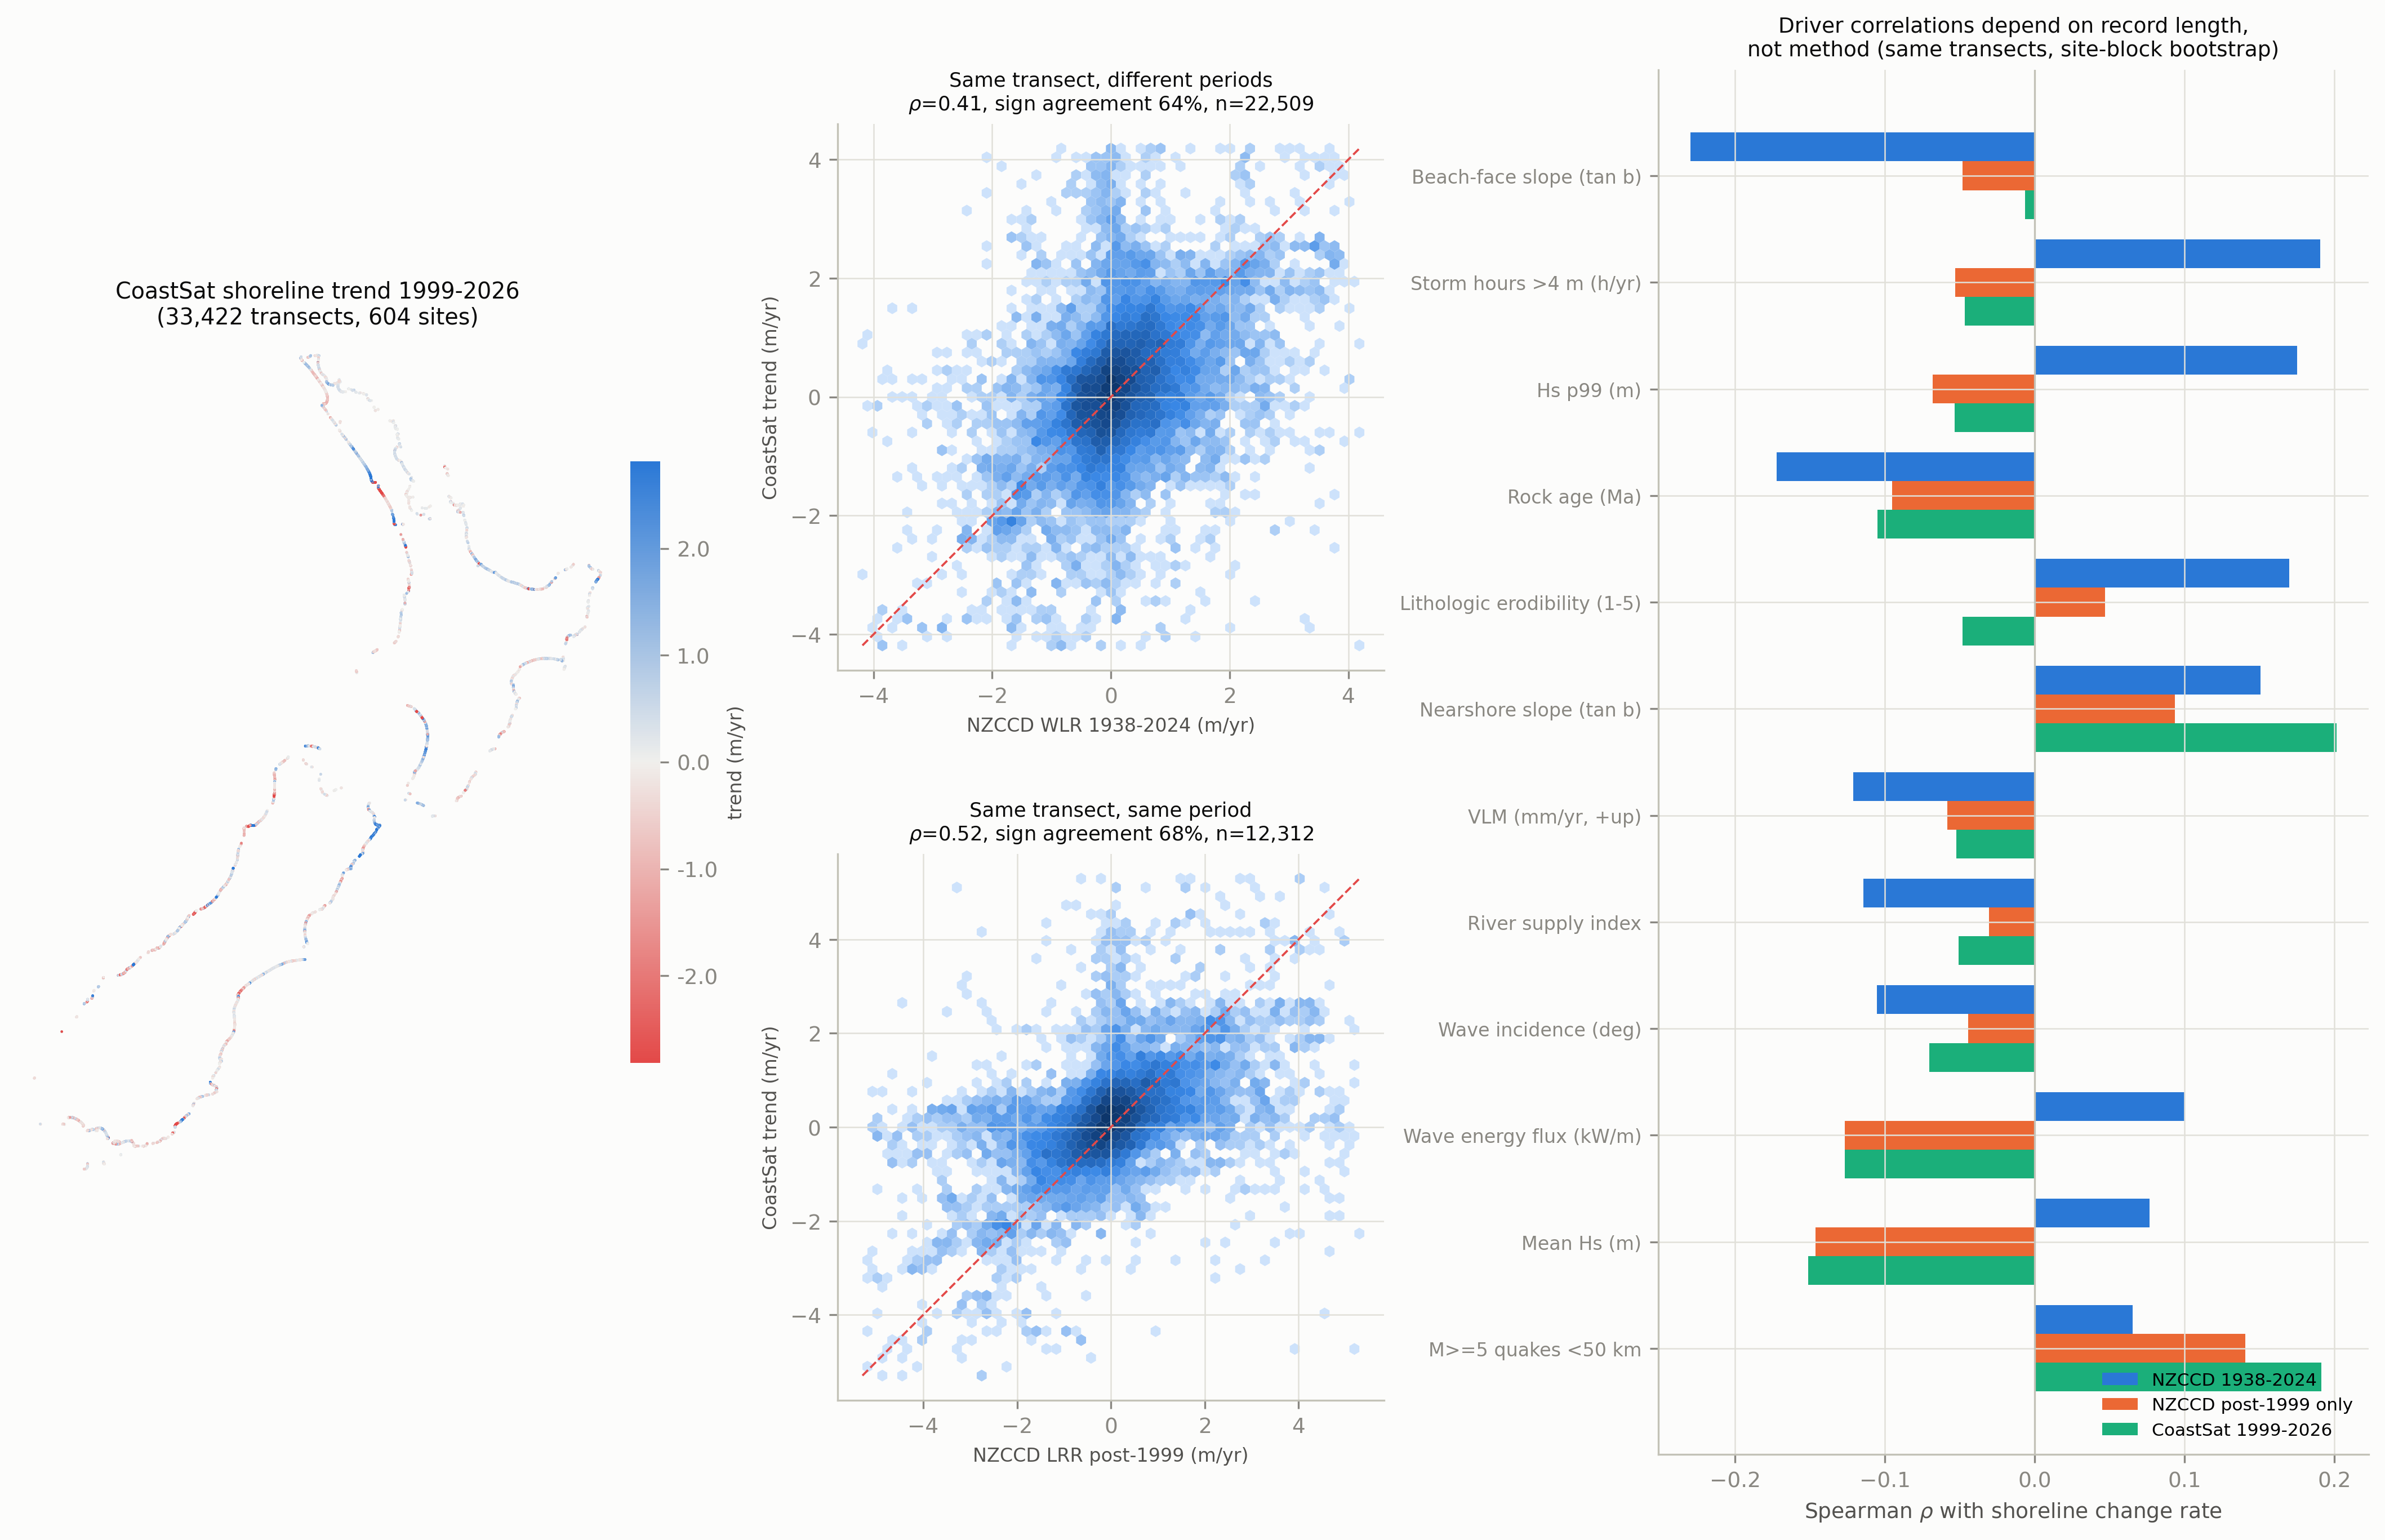

In [6]:
from IPython.display import Image, display
from drivers.figures import FIGS
if not (FIGS / "F8_coastsat.png").exists():
    from drivers.figures import run_extra; run_extra()
display(Image(str(FIGS / "F8_coastsat.png"), width=1000))